In [ ]:
# Project root setup
import os
import sys
from pathlib import Path

ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents) if (path / "src").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Could not locate the project root containing src/.")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [1]:
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from joblib import Parallel, delayed
import os

import src.utils as utils
from src.model import MetMulDagma, MetMulColide

from baselines.colide import colide_ev
from baselines.dagma_linear import DAGMA_linear
from baselines.notears import notears_linear


PATH = './results/samples/'
SAVE = False
LOAD = True
SEED = 10
N_CPUS = max(1, int(os.environ.get('N_CPUS', os.cpu_count() or 1)))
np.random.seed(SEED)
os.makedirs(PATH, exist_ok=True)


/home/srey/Investigacion/cvx_dag_learning/.venv-dag/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Auxiliary functions

In [2]:
# Experiment function
def get_lamb_value(n_nodes, n_samples, times=1):
    return np.sqrt(np.log(n_nodes) / n_samples) * times


def run_samples_exp(g, data_p, N_samples, exps, thr=.2, verb=False):
    shd, tpr, fdr, fscore, err, acyc, runtime, dag_count = [np.zeros((len(N_samples), len(exps))) for _ in range(8)]
    for i, n_samples in enumerate(N_samples):
        if g % N_CPUS == 0:
            print(f'Graph: {g+1}, samples: {n_samples}')

        # Create data
        data_p_aux = data_p.copy()
        data_p_aux['n_samples'] = n_samples

        W_true, _, X = utils.simulate_sem(**data_p_aux)
        X_std = utils.standarize(X)
        W_true_bin = utils.to_bin(W_true, thr)
        norm_W_true = np.linalg.norm(W_true)

        for j, exp in enumerate(exps):
            X_aux = X_std if exp.get('standarize', False) else X

            arg_aux = exp['args'].copy()
            if exp.get('adapt_lamb', False):
                if 'lamb' in arg_aux.keys():
                    arg_aux['lamb'] = get_lamb_value(data_p['n_nodes'], n_samples, arg_aux['lamb'])
                elif 'lambda1' in arg_aux.keys():
                    arg_aux['lambda1'] = get_lamb_value(data_p['n_nodes'], n_samples, arg_aux['lambda1'])

            model = None
            if exp['model'] == notears_linear:
                t_init = perf_counter()
                W_est = notears_linear(X_aux, **arg_aux)
                t_end = perf_counter()
            else:
                model = exp['model'](**exp['init']) if 'init' in exp.keys() else exp['model']()
                t_init = perf_counter()
                model.fit(X_aux, **arg_aux)
                t_end = perf_counter()
                W_est = model.W_est

            if np.isnan(W_est).any():
                W_est = np.zeros_like(W_est)
                W_est_bin = np.zeros_like(W_est)
            else:
                W_est_bin = utils.to_bin(W_est, thr)

            shd[i, j], tpr[i, j], fdr[i, j] = utils.count_accuracy(W_true_bin, W_est_bin)
            fscore[i, j] = f1_score(W_true_bin.flatten(), W_est_bin.flatten())
            err[i, j] = utils.compute_norm_sq_err(W_true, W_est, norm_W_true)
            acyc[i, j] = model.dagness(W_est) if model is not None and hasattr(model, 'dagness') else 1
            runtime[i, j] = t_end - t_init
            dag_count[i, j] += 1 if utils.is_dag(W_est_bin) else 0

            if verb and (g % N_CPUS == 0):
                print(f'	-{exp["leg"]}: shd {shd[i,j]}  -  err: {err[i,j]:.3f}  -  time: {runtime[i,j]:.3f}')

    return shd, tpr, fdr, fscore, err, acyc, runtime, dag_count


def samples_results_prefix(data_p):
    N = data_p['n_nodes']
    return PATH + f'samples_{N}N_{int(data_p["edges"] / N)}'


def save_samples_results(file_prefix, metrics, exps, N_samples):
    shd, tpr, fdr, fscore, err, acyc, runtime, dag_count = metrics
    np.savez(file_prefix, shd=shd, tpr=tpr, fdr=fdr, fscore=fscore, err=err,
             acyc=acyc, runtime=runtime, dag_count=dag_count, exps=exps,
             xvals=N_samples)
    print('SAVED in file:', file_prefix)

    agg_error = np.median(err, axis=0)
    utils.data_to_csv(f'{PATH}samples_err_med.csv', exps, N_samples, agg_error)
    prctile25 = np.percentile(err, 25, axis=0)
    utils.data_to_csv(f'{PATH}samples_err_prctile25.csv', exps, N_samples, prctile25)
    prctile75 = np.percentile(err, 75, axis=0)
    utils.data_to_csv(f'{PATH}samples_err_prctile75.csv', exps, N_samples, prctile75)

    agg_shd = np.mean(shd, axis=0)
    utils.data_to_csv(f'{PATH}samples_shd_mean.csv', exps, N_samples, agg_shd)
    std_shd = np.std(shd, axis=0)
    utils.data_to_csv(f'{PATH}samples_shd_std.csv', exps, N_samples, std_shd)


def load_samples_results(file_prefix):
    file_name = f'{file_prefix}.npz'
    data = np.load(file_name, allow_pickle=True)
    print('Loaded samples results from', file_name)
    return (data['shd'], data['tpr'], data['fdr'], data['fscore'], data['err'],
            data['acyc'], data['runtime'], data['dag_count'], data['exps'].tolist(), data['xvals'])


def run_or_load_samples_results(data_p, N_samples, exps, n_dags, thr=.2, verb=False):
    file_prefix = samples_results_prefix(data_p)

    if LOAD:
        return load_samples_results(file_prefix)

    n_jobs = max(1, min(N_CPUS, n_dags))
    print('CPUs employed:', n_jobs)

    t_init = perf_counter()
    results = Parallel(n_jobs=n_jobs)(delayed(run_samples_exp)
                                      (g, data_p, N_samples, exps, thr, verb) for g in range(n_dags))
    t_end = perf_counter()
    print(f'----- Solved in {(t_end-t_init)/60:.3f} minutes -----')

    metrics = tuple(np.asarray(metric) for metric in zip(*results))
    if SAVE:
        save_samples_results(file_prefix, metrics, exps, N_samples)

    return (*metrics, exps, N_samples)


## Without standarizing

In [ ]:
from baselines.golem import GOLEM_TF_EV
from baselines.nonnegative_dagma_linear import NonnegativeDAGMA_linear


n_dags = 50
N_samples = np.array( [50, 60, 80, 100, 200, 500, 1000, 5000, 10000] )

# DEFINE EXPERIMENTS
Exps = [
  # NOMAD
  {'model': MetMulDagma, 'args': {'stepsize': 3e-4, 'step_type': 'fixed', 'alpha_0': .01, 'rho_0': .05, 's': 1, 'lamb': 1e-1,
   'iters_in': 10000, 'iters_out': 10, 'beta': 2}, 'init': {'primal_opt': 'adam', 'acyclicity': 'logdet'},
   'adapt_lamb': True, 'standarize': False, 'fmt': 'o-', 'leg': 'NOMAD-adam'},

  {'model': MetMulDagma, 'args': {'stepsize': 1e-5, 'step_type': 'fixed', 'alpha_0': .01, 'rho_0': .01, 's': 1, 'lamb': .2,
   'iters_in': 10000, 'iters_out': 50, 'beta': 1.5}, 'init': {'acyclicity': 'logdet', 'primal_opt': 'fista', 'restart': True},
     'adapt_lamb': True, 'standarize': False, 'fmt': 'o--', 'leg': 'NOMAD-fista'},

  # # MM + Cvx COLIDE
  # {'model': MetMulColide, 'args': {'stepsize': 3e-4, 'alpha_0': .01, 'rho_0': .05, 's': 1, 'lamb': .1, 'iters_in': 20000,
  #    'iters_out': 10, 'beta': 2, 'sca_adam': True}, 'init': {'acyclicity': 'logdet', 'primal_opt': 'sca'},
  #    'adapt_lamb': True, 'standarize': False, 'fmt': 's-', 'leg': 'MM-Col-sca'},

  # NoTears
  # {'model': notears_linear, 'args': {'loss_type': 'l2', 'lambda1': .1, 'max_iter': 4}, 'standarize': False,  'fmt': '>-', 'leg': 'NoTears'},
  
  # DAGMA
  {'model': DAGMA_linear, 'init': {'loss_type': 'l2'}, 'args': {'lambda1': .05, 'T': 4, 's': [1.0, .9, .8, .7],
   'warm_iter': 2e4, 'max_iter': 7e4, 'lr': .0003}, 'standarize': False, 'fmt': '^-', 'leg': 'DAGMA'},
  
  {'model': NonnegativeDAGMA_linear, 'init': {'loss_type': 'l2'}, 'args': {'lambda1': .05, 'T': 4, 's': [1.0, .9, .8, .7],
   'warm_iter': 2e4, 'max_iter': 7e4, 'lr': .0003}, 'standarize': False, 'adapt_lamb': False, 'fmt': 's--', 'leg': 'NonDAGMA-Fix'},

  {'model': NonnegativeDAGMA_linear, 'init': {'loss_type': 'l2'}, 'args': {'lambda1': .74, 'T': 4, 's': [1.0, .9, .8, .7],
   'warm_iter': 2e4, 'max_iter': 7e4, 'lr': .0003}, 'standarize': False, 'adapt_lamb': True, 'fmt': 's-', 'leg': 'NonDAGMA'},

  # Colide
  {'model': colide_ev, 'args': {'lambda1': .05, 'T': 4, 's': [1.0, .9, .8, .7], 'warm_iter': 2e4,
   'max_iter': 7e4, 'lr': .0003}, 'standarize': False, 'fmt': 'v--', 'leg': 'CoLiDE-Fix'},

  {'model': colide_ev, 'args': {'lambda1': .74, 'T': 4, 's': [1.0, .9, .8, .7], 'warm_iter': 2e4,
   'max_iter': 7e4, 'lr': .0003}, 'standarize': False, 'adapt_lamb': True, 'fmt': 'v-', 'leg': 'CoLiDE'},

  # GOLEM
  {'model': GOLEM_TF_EV, 'args': {'lambda1': 2e-2, 'lambda2': 5.0, 'num_iter': 100000, 'learning_rate': 1e-3, 'w_threshold': 0.3,
   'postprocess': True, 'checkpoint': None}, 'standarize': False, 'adapt_lamb': True, 'fmt': '>--', 'leg': 'GOLEM-EV-Fix'},
  
  {'model': GOLEM_TF_EV, 'args': {'lambda1': 0.3, 'lambda2': 5.0, 'num_iter': 100000, 'learning_rate': 1e-3, 'w_threshold': 0.3,
   'postprocess': True, 'checkpoint': None}, 'standarize': False, 'adapt_lamb': True, 'fmt': '>-', 'leg': 'GOLEM-EV'},
]

### 100 nodes - unit variance

In [4]:
N = 100
thr = .2
verb = True
data_p = {
    'n_nodes': N,
    'graph_type': 'er',
    'edges': 4*N,
    'edge_type': 'positive',
    'w_range': (.5, 1),
    'var': 1,
}

shd, tpr, fdr, fscore, err, acyc, runtime, dag_count, Exps, N_samples = run_or_load_samples_results(
    data_p, N_samples, Exps, n_dags, thr=thr, verb=verb
)


Loaded samples results from ./results/samples/samples_100N_4.npz


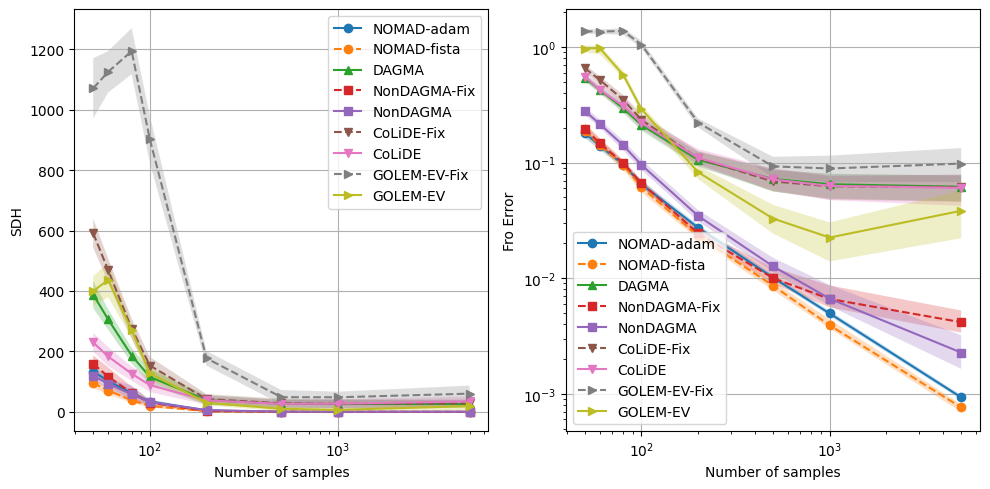

In [5]:
skip = []

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
utils.plot_data(axes[0], shd, Exps, N_samples, 'Number of samples', 'SDH', skip,
                agg='mean', deviation='std', alpha=0.25)
utils.plot_data(axes[1], err, Exps, N_samples, 'Number of samples', 'Fro Error', skip,
                agg='median', deviation='prctile', alpha=0.25, plot_func='loglog')
plt.tight_layout()


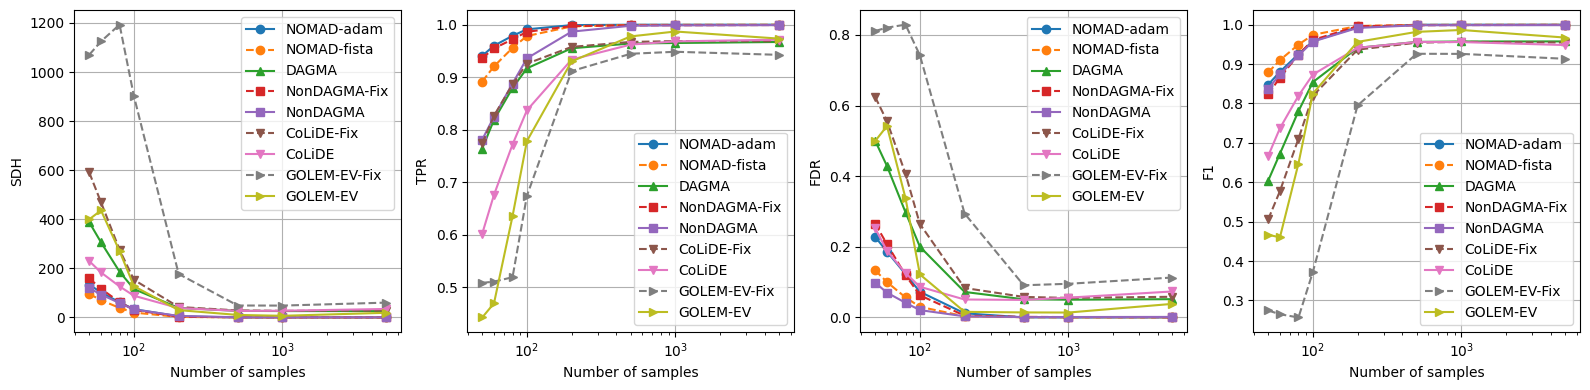

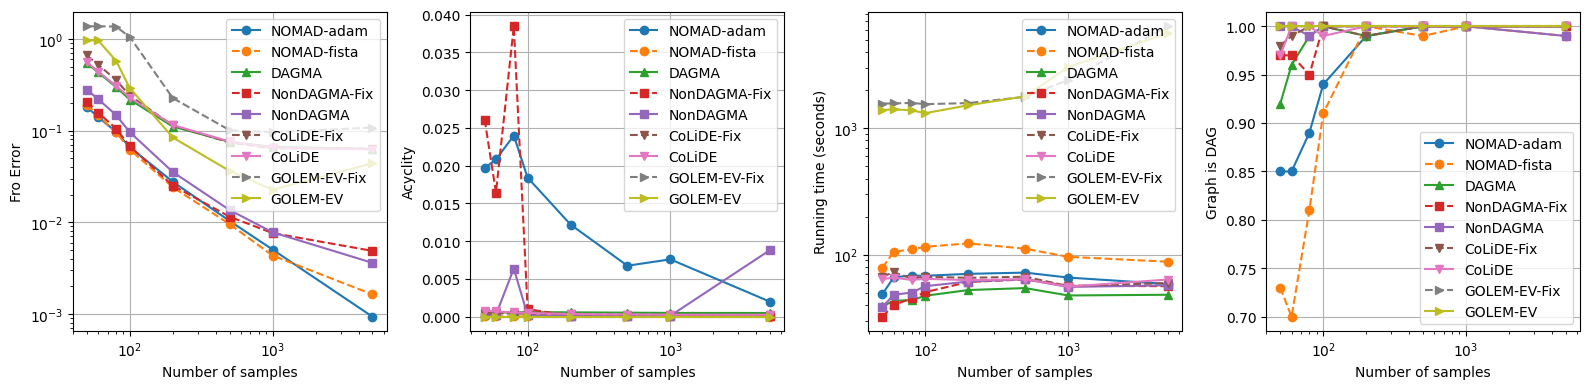

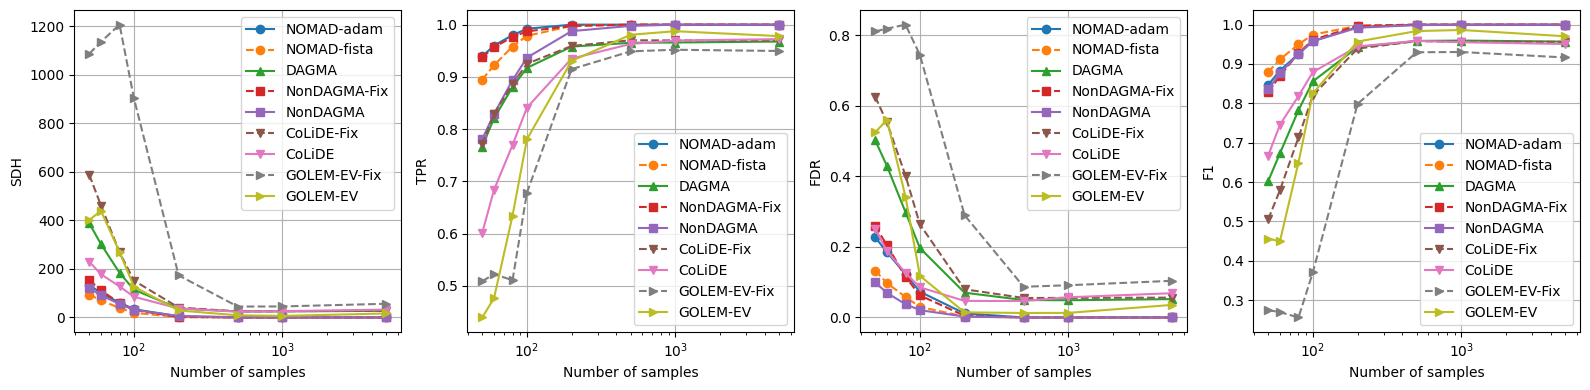

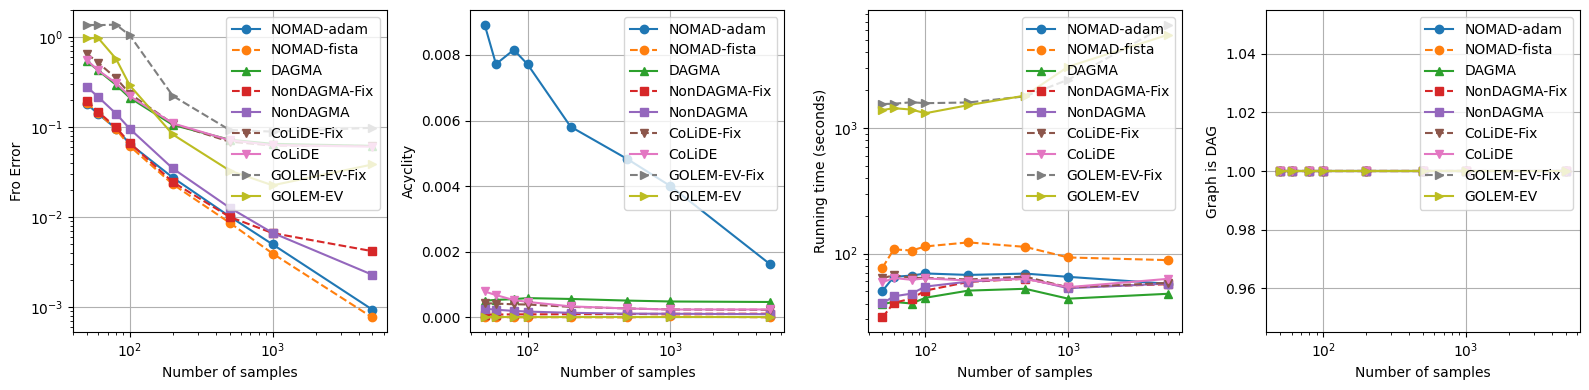

In [6]:
skip = [] # [2]
utils.plot_all_metrics(shd, tpr, fdr, fscore, err, acyc, runtime, dag_count, N_samples, Exps,
                 skip_idx=skip, agg='mean')

utils.plot_all_metrics(shd, tpr, fdr, fscore, err, acyc, runtime, dag_count, N_samples, Exps,
                 skip_idx=skip, agg='median')


In [7]:
# Set LOAD = True in the first cell to load this data instead of running the experiment.
# The default file for the current scenario is: ./results/samples/samples_100N_4.npz
